<a href="https://colab.research.google.com/github/sampujya123/PaySHIELD/blob/main/PS_4_1_SMOTE_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

train_df = pd.read_csv("train_data.csv")
test_df = pd.read_csv("test_data.csv")

# Split features and labels
X_train = train_df.drop("fraud_flag", axis=1)
y_train = train_df["fraud_flag"]

X_test = test_df.drop("fraud_flag", axis=1)
y_test = test_df["fraud_flag"]

print(X_train.shape, X_test.shape)

(200000, 30) (50000, 30)


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import pandas as pd

ratios = {
    "No_SMOTE": None,
    "1:1": 1.0,
    "1:2": 0.5,
    "1:3": 0.33,
    "1:4": 0.25,
    "1:5": 0.2,
    "1:6": 0.17
}

results = []

for name, ratio in ratios.items():

    print(f"\nRunning: {name}")

    if ratio is None:
        X_res, y_res = X_train, y_train
    else:
        smote = SMOTE(
            sampling_strategy=ratio,
            random_state=42
        )
        X_res, y_res = smote.fit_resample(
            X_train,
            y_train
        )

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_res, y_res)

    y_pred = model.predict(X_test)

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    results.append({
        "Ratio": name,
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1": report["1"]["f1-score"]
    })

df_results = pd.DataFrame(results)

print(df_results)

df_results.to_csv("smote_comparison_results.csv", index=False)


Running: No_SMOTE

Running: 1:1

Running: 1:2

Running: 1:3

Running: 1:4

Running: 1:5

Running: 1:6
      Ratio  Precision    Recall        F1
0  No_SMOTE   0.526119  0.140719  0.222047
1       1:1   0.421324  0.489022  0.452656
2       1:2   0.419525  0.476048  0.446003
3       1:3   0.425494  0.473054  0.448015
4       1:4   0.420057  0.443114  0.431277
5       1:5   0.426291  0.453094  0.439284
6       1:6   0.419132  0.424152  0.421627


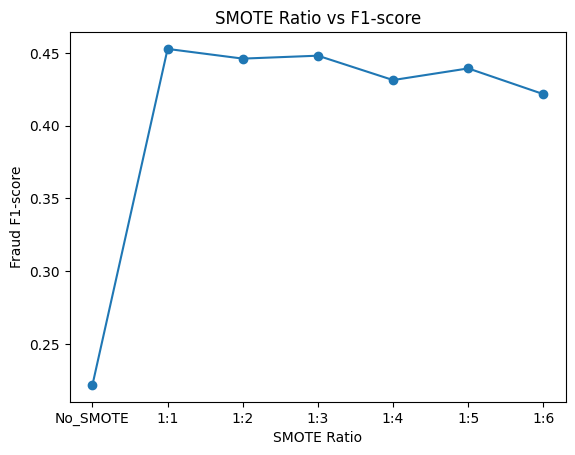

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(
    df_results["Ratio"],
    df_results["F1"],
    marker="o"
)

plt.title("SMOTE Ratio vs F1-score")
plt.xlabel("SMOTE Ratio")
plt.ylabel("Fraud F1-score")

plt.show()